In [1]:
# Imports (keep in one place)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
 )

import xgboost as xgb
from xgboost import XGBClassifier

In [2]:
# Data load
df = pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Базовая сводка по данным
df.info()

# Описательная статистика (числовые признаки)
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### Описание признаков

*   **Time**: Количество секунд, прошедших между этой транзакцией и первой транзакцией в наборе данных.
*   **Amount**: Сумма транзакции.
*   **V1-V28**: Анонимизированные признаки, которые могут быть результатом PCA-преобразования для защиты конфиденциальности пользователей.
*   **Class**: Целевая переменная (1 - мошенничество, 0 - обычная транзакция).

Class
0    284315
1       492
Name: count, dtype: int64


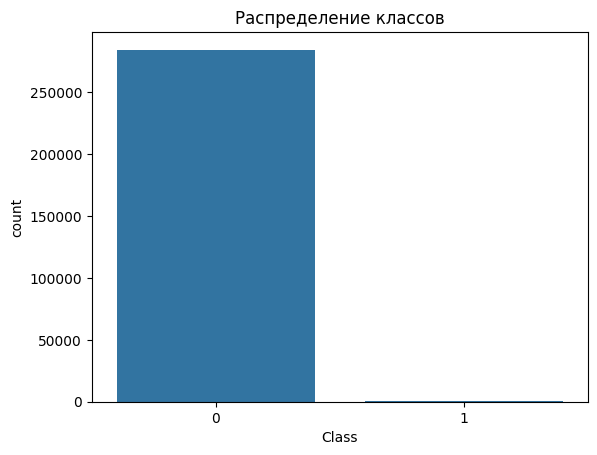

In [4]:
print(df['Class'].value_counts())

# Визуализация распределения классов
sns.countplot(x='Class', data=df)
plt.title('Распределение классов')
plt.show()

### Борьба с дисбалансом классов: Undersampling (как эксперимент)

Ниже мы сделаем простой undersampling, чтобы **визуально** и на маленьком примере увидеть поведение на сбалансированных данных.

Важно: **дальше в baseline/сравнении/Optuna мы обучаемся на полном датасете** (со всеми объектами), а дисбаланс учитываем через веса (`class_weight`, `scale_pos_weight`).

Новое распределение классов:
Class
0    492
1    492
Name: count, dtype: int64


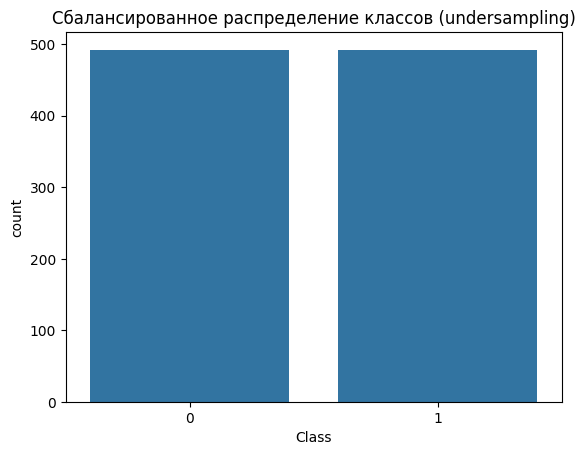

In [5]:
# Отделяем мошеннические и обычные транзакции
fraud_df = df[df['Class'] == 1]
non_fraud_df = df[df['Class'] == 0]

# Случайно выбираем обычные транзакции в том же количестве, что и мошеннические
non_fraud_sample = non_fraud_df.sample(n=len(fraud_df), random_state=42)

# Создаём новый сбалансированный датафрейм
balanced_df = pd.concat([fraud_df, non_fraud_sample])

# Перемешиваем данные
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Новое распределение классов:')
print(balanced_df['Class'].value_counts())

# Визуализация
sns.countplot(x='Class', data=balanced_df)
plt.title('Сбалансированное распределение классов (undersampling)')
plt.show()

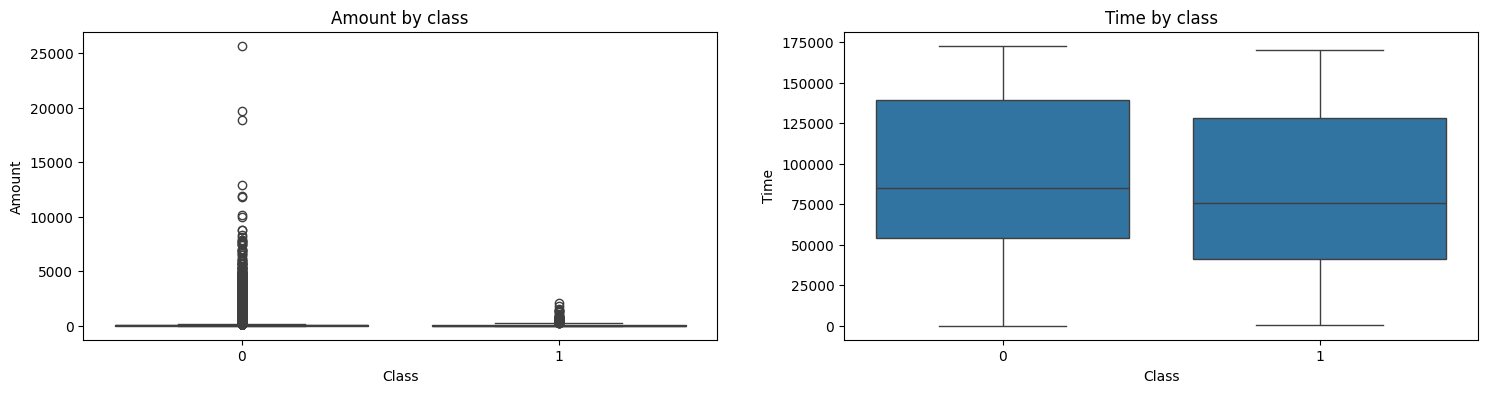

In [6]:
# Boxplots for raw interpretables (Time/Amount)
if {'Amount', 'Time'}.issubset(df.columns):
    fig, ax = plt.subplots(1, 2, figsize=(18, 4))

    sns.boxplot(x='Class', y='Amount', data=df, ax=ax[0])
    ax[0].set_title('Amount by class')

    sns.boxplot(x='Class', y='Time', data=df, ax=ax[1])
    ax[1].set_title('Time by class')

    plt.show()
else:
    print('Skipping boxplots: Time/Amount are not available (likely already scaled & dropped).')

### `Time` и `Amount` в зависимости от класса

Сравним распределения `Time` и `Amount` для мошеннических и обычных транзакций.

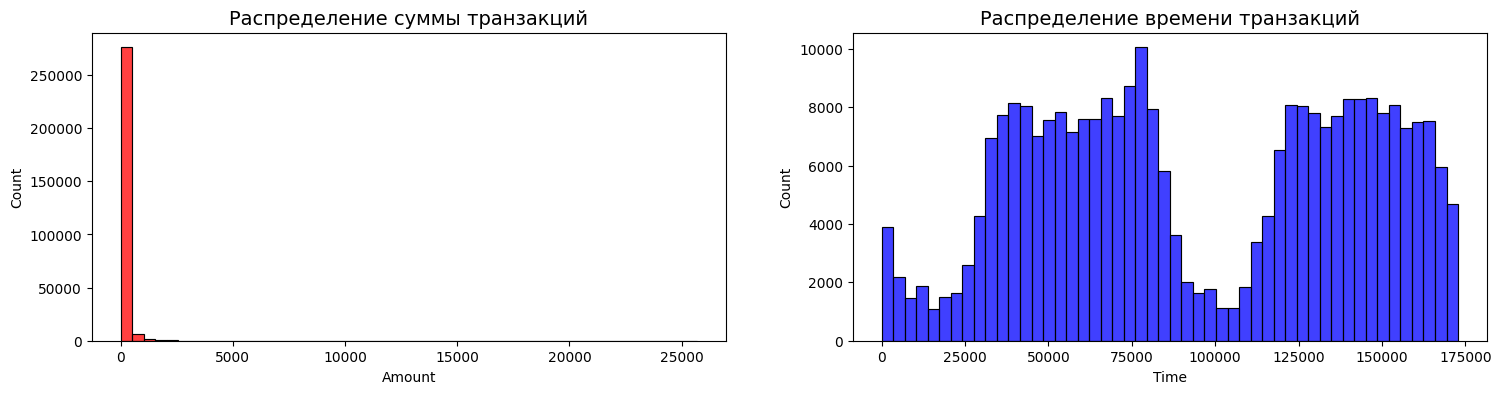

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

sns.histplot(df['Amount'], ax=ax[0], color='r', bins=50)
ax[0].set_title('Распределение суммы транзакций', fontsize=14)

sns.histplot(df['Time'], ax=ax[1], color='b', bins=50)
ax[1].set_title('Распределение времени транзакций', fontsize=14)

plt.show()

### Визуализация интерпретируемых признаков (`Time`, `Amount`)

Признаки V1–V28 анонимизированы (PCA), поэтому для интерпретируемого EDA отдельно посмотрим на `Time` и `Amount`.

## Препроцессинг: масштабирование `Time` и `Amount`

Остальные признаки (`V1–V28`) уже нормализованы (PCA), но `Time` и `Amount` — нет. Поэтому стандартизируем их и удаляем исходные колонки.

In [8]:
scaler = StandardScaler()

# If you rerun the notebook, Time/Amount might already be dropped — keep this cell idempotent.
if 'Amount' in df.columns:
    df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
if 'Time' in df.columns:
    df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

cols_to_drop = [c for c in ['Time', 'Amount'] if c in df.columns]
if cols_to_drop:
    df.drop(cols_to_drop, axis=1, inplace=True)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [9]:
# Features / target
X = df.drop(columns=['Class'])
y = df['Class']

# Stratified split is a must for imbalanced data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
 )

# Logistic Regression baseline
lr = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    random_state=42,
    max_iter=2000,
 )

lr.fit(X_train, y_train)

y_proba_lr = lr.predict_proba(X_test)[:, 1]
y_pred_lr = (y_proba_lr >= 0.5).astype(int)

print('LogReg ROC-AUC:', roc_auc_score(y_test, y_proba_lr))
print('LogReg PR-AUC (AP):', average_precision_score(y_test, y_proba_lr))
print('\nConfusion matrix (threshold=0.5):')
print(confusion_matrix(y_test, y_pred_lr))
print('\nClassification report:')
print(classification_report(y_test, y_pred_lr, digits=4))

LogReg ROC-AUC: 0.9720948047902335
LogReg PR-AUC (AP): 0.7189348125855012

Confusion matrix (threshold=0.5):
[[55478  1386]
 [    8    90]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962



## Baseline: логистическая регрессия (учёт дисбаланса)

Делаем первый честный baseline на *исходном дисбалансе*, но с `class_weight='balanced'`.
Смотрим ROC-AUC и PR-AUC (AP), а также confusion matrix при пороге 0.5.

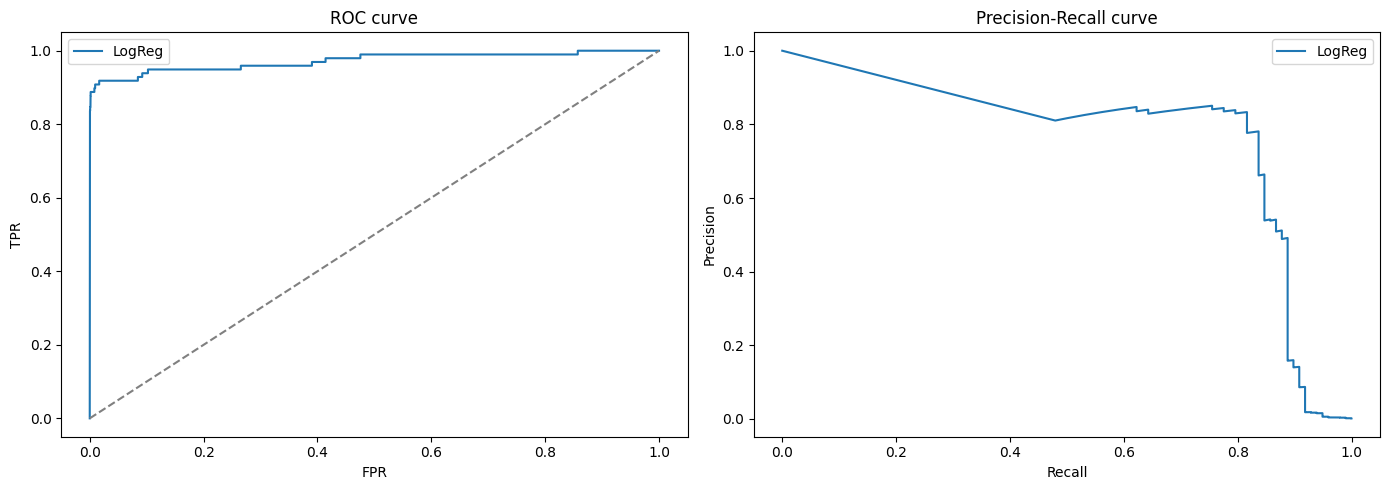

In [10]:
# ROC и PR кривые (после обучения модели)
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
prec, rec, _ = precision_recall_curve(y_test, y_proba_lr)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(fpr, tpr, label='LogReg')
ax[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
ax[0].set_title('ROC curve')
ax[0].set_xlabel('FPR')
ax[0].set_ylabel('TPR')
ax[0].legend()

ax[1].plot(rec, prec, label='LogReg')
ax[1].set_title('Precision-Recall curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.tight_layout()
plt.show()

## Сравнение моделей: LogReg vs RandomForest vs XGBoost

Сравним модели на одном и том же `train/test split` и посмотрим ROC-AUC и PR-AUC (Average Precision).

Для XGBoost учитываем дисбаланс через `scale_pos_weight ≈ N_neg / N_pos` на трейне.

In [11]:
# Helper for comparison
def eval_model(name, model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'model': name,
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
    }

# RandomForest baseline
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',
 )
rf.fit(X_train, y_train)

# XGBoost baseline
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = float(neg) / float(pos)

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
 )
xgb.fit(X_train, y_train)

results = []
results.append({
    'model': 'LogReg',
    'roc_auc': roc_auc_score(y_test, y_proba_lr),
    'pr_auc': average_precision_score(y_test, y_proba_lr),
})
results.append(eval_model('RandomForest', rf, X_test, y_test))
results.append(eval_model('XGBoost', xgb, X_test, y_test))

results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
results_df

,model,roc_auc,pr_auc
2,XGBoost,0.984916,0.871297
1,RandomForest,0.961545,0.865242
0,LogReg,0.972095,0.718935


## Optuna: тюнинг XGBoost под PR-AUC

В `xgboost==3.x` у sklearn-обёртки изменился API ранней остановки, поэтому для Optuna используем `xgboost.train()` + `DMatrix`, где `early_stopping_rounds` работает корректно.

## Бизнес-метрики и виртуальный A/B на holdout

Датасет сильно несбалансирован, поэтому “обычные” метрики качества модели (ROC-AUC/PR-AUC) — это только часть истории.
В проде нам нужно выбрать *policy*: кого отправляем на ручную проверку/блокируем.

Ниже посчитаем:
- **Precision@K / Recall@K** (если проверяем top-K самых рискованных транзакций)
- ожидаемую стоимость ошибок через **cost matrix**
- сравнение политик (baseline vs tuned) на `X_test` как виртуальный A/B.

In [12]:
# Business assumptions (cost matrix)
COST_FN = 100.0
COST_FP = 1.0

# K — how many transactions we can manually review / block
K = 1000

models_proba = {
    'LogReg': y_proba_lr,
}

y_proba_opt_safe = globals().get('y_proba_opt', None)
if y_proba_opt_safe is not None:
    models_proba['Tuned_XGB'] = y_proba_opt_safe

if 'xgb' in globals():
    try:
        models_proba['XGB_baseline'] = xgb.predict_proba(X_test)[:, 1]
    except Exception:
        pass

assert set(np.unique(y_test)).issubset({0, 1}), 'y_test should be binary 0/1'

In [13]:
def precision_recall_at_k(y_true: np.ndarray, y_score: np.ndarray, k: int) -> dict:
    k = int(k)
    if k <= 0:
        raise ValueError('k must be > 0')
    k = min(k, len(y_true))

    order = np.argsort(-y_score)
    topk = order[:k]

    y_top = y_true[topk]
    tp = int(np.sum(y_top == 1))
    fp = int(np.sum(y_top == 0))
    total_pos = int(np.sum(y_true == 1))

    precision = tp / max(tp + fp, 1)
    recall = tp / max(total_pos, 1)

    return {
        'k': k,
        'tp': tp,
        'fp': fp,
        'precision@k': precision,
        'recall@k': recall,
    }


def cost_at_threshold(y_true: np.ndarray, y_score: np.ndarray, thr: float, cost_fn: float, cost_fp: float) -> dict:
    y_pred = (y_score >= thr).astype(int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))

    total_cost = fn * cost_fn + fp * cost_fp
    return {
        'threshold': float(thr),
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'total_cost': float(total_cost),
    }


def find_best_threshold(y_true: np.ndarray, y_score: np.ndarray, cost_fn: float, cost_fp: float, n_grid: int = 200) -> dict:
    # Грид по вероятностям; берём квантили чтобы не тратить время на пустые области
    qs = np.linspace(0.0, 1.0, n_grid)
    grid = np.quantile(y_score, qs)
    grid = np.unique(grid)

    best = None
    for thr in grid:
        res = cost_at_threshold(y_true, y_score, float(thr), cost_fn, cost_fp)
        if (best is None) or (res['total_cost'] < best['total_cost']):
            best = res
    return best

In [14]:
# Считаем метрики для всех доступных моделей
y_true = y_test.to_numpy() if hasattr(y_test, 'to_numpy') else np.asarray(y_test)

rows = []
for name, proba in models_proba.items():
    y_score = np.asarray(proba)
    prk = precision_recall_at_k(y_true, y_score, K)
    best_thr = find_best_threshold(y_true, y_score, COST_FN, COST_FP)
    baseline_05 = cost_at_threshold(y_true, y_score, 0.5, COST_FN, COST_FP)

    rows.append({
        'model': name,
        'K': prk['k'],
        'precision@K': prk['precision@k'],
        'recall@K': prk['recall@k'],
        'TP@K': prk['tp'],
        'FP@K': prk['fp'],
        'best_threshold': best_thr['threshold'],
        'cost@0.5': baseline_05['total_cost'],
        'cost@best_thr': best_thr['total_cost'],
        'FP@best_thr': best_thr['fp'],
        'FN@best_thr': best_thr['fn'],
    })

metrics_df = pd.DataFrame(rows).sort_values('cost@best_thr')
metrics_df

,model,K,precision@K,recall@K,TP@K,FP@K,best_threshold,cost@0.5,cost@best_thr,FP@best_thr,FN@best_thr
1,XGB_baseline,1000,0.089,0.908163,89,911,0.050268,1525.0,1199.0,199,10
0,LogReg,1000,0.089,0.908163,89,911,0.925481,2186.0,1300.0,200,11


In [15]:
# Виртуальный A/B: baseline (LogReg) vs лучшая модель по cost@best_thr
if len(metrics_df) >= 2 and 'LogReg' in metrics_df['model'].values:
    best_model_name = metrics_df.iloc[0]['model']
    if best_model_name == 'LogReg' and len(metrics_df) > 1:
        best_model_name = metrics_df.iloc[1]['model']

    def summarize_policy(name: str):
        y_score = np.asarray(models_proba[name])
        best_thr = find_best_threshold(y_true, y_score, COST_FN, COST_FP)
        cost = best_thr['total_cost']
        fp = best_thr['fp']
        fn = best_thr['fn']
        tp = best_thr['tp']
        return {
            'model': name,
            'threshold': best_thr['threshold'],
            'TP': tp,
            'FP': fp,
            'FN': fn,
            'total_cost': cost,
        }

    ab_df = pd.DataFrame([summarize_policy('LogReg'), summarize_policy(best_model_name)])
    ab_df['delta_cost_vs_logreg'] = ab_df['total_cost'] - float(ab_df.loc[ab_df['model']=='LogReg', 'total_cost'].iloc[0])
    ab_df
else:
    print('Недостаточно моделей для A/B (нужны хотя бы LogReg и ещё одна модель).')

### Precision@K / Recall@K кривые

Посмотрим, как меняются Precision и Recall при разных бюджетах ручной проверки (разных K).

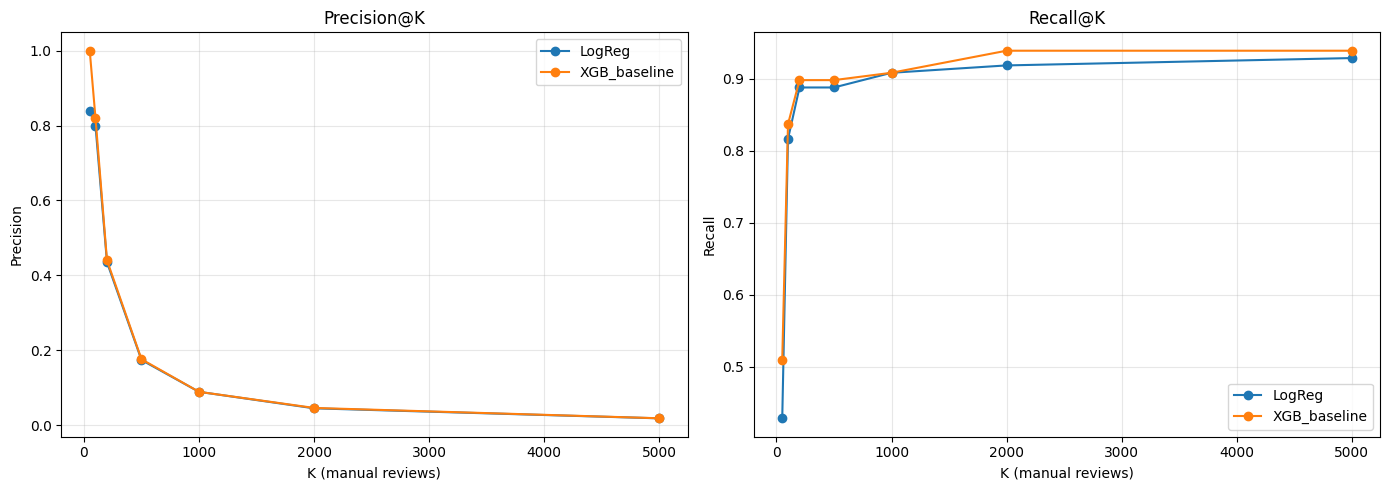

,model,K,precision,recall,TP,FP
0,LogReg,50,0.8400,0.428571,42,8
1,LogReg,100,0.8000,0.816327,80,20
2,LogReg,200,0.4350,0.887755,87,113
3,LogReg,500,0.1740,0.887755,87,413
4,LogReg,1000,0.0890,0.908163,89,911
5,LogReg,2000,0.0450,0.918367,90,1910
6,LogReg,5000,0.0182,0.928571,91,4909
7,XGB_baseline,50,1.0000,0.510204,50,0
8,XGB_baseline,100,0.8200,0.836735,82,18
9,XGB_baseline,200,0.4400,0.897959,88,112


In [16]:
# K grid (budget of manual review)
Ks = [50, 100, 200, 500, 1000, 2000, 5000]
Ks = [k for k in Ks if k <= len(y_true)]

prk_rows = []
for model_name, proba in models_proba.items():
    y_score = np.asarray(proba)
    for k in Ks:
        d = precision_recall_at_k(y_true, y_score, k)
        prk_rows.append({
            'model': model_name,
            'K': d['k'],
            'precision': d['precision@k'],
            'recall': d['recall@k'],
            'TP': d['tp'],
            'FP': d['fp'],
        })

prk_df = pd.DataFrame(prk_rows)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for model_name in prk_df['model'].unique():
    sub = prk_df[prk_df['model'] == model_name].sort_values('K')
    ax[0].plot(sub['K'], sub['precision'], marker='o', label=model_name)
    ax[1].plot(sub['K'], sub['recall'], marker='o', label=model_name)

ax[0].set_title('Precision@K')
ax[0].set_xlabel('K (manual reviews)')
ax[0].set_ylabel('Precision')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].set_title('Recall@K')
ax[1].set_xlabel('K (manual reviews)')
ax[1].set_ylabel('Recall')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

prk_df.sort_values(['model', 'K']).head(10)

### Ожидаемая стоимость vs threshold

Для одной и той же модели в зависимости от порога меняется баланс FP/FN.
Построим зависимость total_cost от threshold (по нашей cost matrix).

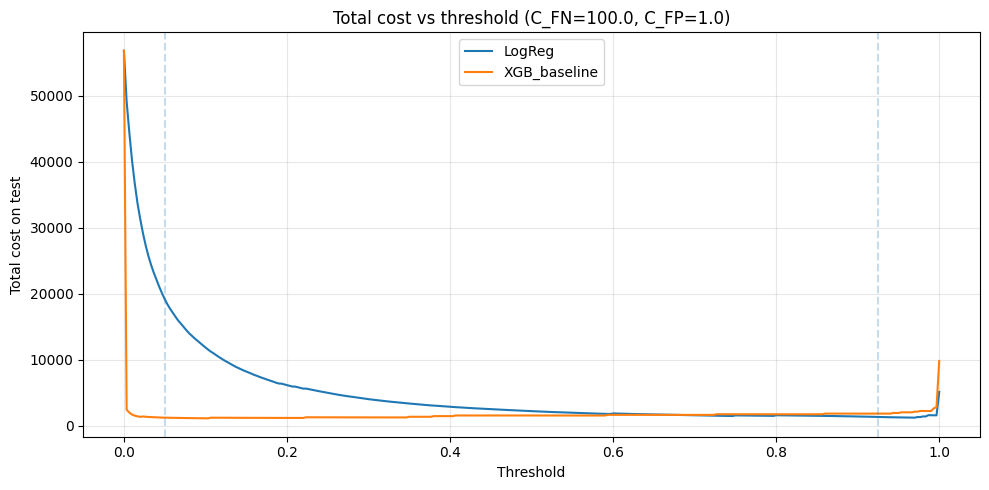

In [17]:
# Грид threshold (равномерный)
thr_grid = np.linspace(0.0, 1.0, 301)

plt.figure(figsize=(10, 5))

for model_name, proba in models_proba.items():
    y_score = np.asarray(proba)
    costs = [cost_at_threshold(y_true, y_score, float(t), COST_FN, COST_FP)['total_cost'] for t in thr_grid]
    plt.plot(thr_grid, costs, label=model_name)

# Отметим best_thr из таблицы
for _, row in metrics_df.iterrows():
    plt.axvline(row['best_threshold'], linestyle='--', alpha=0.25)

plt.title(f'Total cost vs threshold (C_FN={COST_FN}, C_FP={COST_FP})')
plt.xlabel('Threshold')
plt.ylabel('Total cost on test')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Кросс-валидация (StratifiedKFold)

Один train/test split полезен, но качество может зависеть от конкретного разбиения.
Поэтому дополнительно посчитаем метрики на **кросс-валидации** (StratifiedKFold), чтобы оценка была стабильнее.

Метрики:
- ROC-AUC
- PR-AUC (Average Precision)

In [18]:
# Model contract for CV: fit on train-fold, evaluate proba on val-fold
def cv_eval_proba(model, X, y, n_splits: int = 5, random_state: int = 42) -> pd.DataFrame:
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []
    X_np = X.values if hasattr(X, 'values') else np.asarray(X)
    y_np = y.values if hasattr(y, 'values') else np.asarray(y)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_np, y_np), start=1):
        X_tr_f, X_val_f = X_np[tr_idx], X_np[val_idx]
        y_tr_f, y_val_f = y_np[tr_idx], y_np[val_idx]

        m = clone(model)
        m.fit(X_tr_f, y_tr_f)
        y_val_proba = m.predict_proba(X_val_f)[:, 1]

        rows.append({
            'fold': fold,
            'roc_auc': roc_auc_score(y_val_f, y_val_proba),
            'pr_auc': average_precision_score(y_val_f, y_val_proba),
        })

    return pd.DataFrame(rows)

cv_models = {
    'LogReg_balanced': LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        random_state=42,
        max_iter=2000,
    ),
}

neg_full = int((y == 0).sum())
pos_full = int((y == 1).sum())
scale_pos_weight_full = neg_full / max(pos_full, 1)

cv_models['XGB_baseline'] = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    scale_pos_weight=scale_pos_weight_full,
 )

study_obj = globals().get('study', None)
best_params_obj = getattr(study_obj, 'best_params', None) if study_obj is not None else None
if isinstance(best_params_obj, dict) and len(best_params_obj) > 0:
    tuned_params = {
        'learning_rate': best_params_obj.get('eta', 0.05),
        'max_depth': best_params_obj.get('max_depth', 4),
        'min_child_weight': best_params_obj.get('min_child_weight', 1.0),
        'subsample': best_params_obj.get('subsample', 0.8),
        'colsample_bytree': best_params_obj.get('colsample_bytree', 0.8),
        'gamma': best_params_obj.get('gamma', 0.0),
        'reg_lambda': best_params_obj.get('lambda', 1.0),
        'reg_alpha': best_params_obj.get('alpha', 0.0),
    }
    cv_models['XGB_tuned_like'] = XGBClassifier(
        n_estimators=1200,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        scale_pos_weight=scale_pos_weight_full,
        **tuned_params,
    )

In [19]:
# Прогоняем CV и собираем сводную таблицу
cv_results = []
for name, model in cv_models.items():
    folds_df = cv_eval_proba(model, X, y, n_splits=5, random_state=42)
    cv_results.append({
        'model': name,
        'roc_auc_mean': folds_df['roc_auc'].mean(),
        'roc_auc_std': folds_df['roc_auc'].std(ddof=1),
        'pr_auc_mean': folds_df['pr_auc'].mean(),
        'pr_auc_std': folds_df['pr_auc'].std(ddof=1),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('pr_auc_mean', ascending=False)
cv_results_df

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
1,XGB_baseline,0.982178,0.009227,0.865547,0.026778
0,LogReg_balanced,0.979515,0.008759,0.729282,0.028585


### Вывод по CV

На 5-fold StratifiedKFold видно, что XGBoost стабильно выигрывает у LogReg по PR-AUC (что ожидаемо при сильном дисбалансе).

Важно: Optuna-тюнинг оптимизировали по внутреннему valid на одном разбиении, поэтому в CV он может быть не лучше baseline — это нормально. Для “железного” тюнинга делают nested-CV или отдельный final refit + проверку на holdout (что у нас уже есть).